[TOC](../toc.ipynb)

Advanced topics in nonlinear algebra
====================================

- KEYWORDS: scipy.optimize.root, numpy.polynomial.Polynomial


# Special nonlinear systems - polynomials



Polynomials are a special class of nonlinear algebraic equations that are especially easy to solve. A polynomial is linear in the coefficients in front of the variable. If we consider the following $n^{th}$ order polynomial:

$c_0 + c_1x + c_2x^2 + \cdots + c_nx^n = 0$

Let's be specific:

$x^2 + 8x + 16 = 0$

The modern `numpy.polynomial.Polynomial` API stores coefficients in order of increasing degree,
so we express this polynomial as `[16, 8, 1]`.

In [1]:
import numpy as np
from numpy.polynomial import Polynomial

?Polynomial

In [2]:
poly = Polynomial([16, 8, 1])
r = poly.roots()
r

array([-4.00000004, -3.99999996])

In [3]:
r**2 + 8 * r + 16

array([0.00000000e+00, 1.77635684e-15])

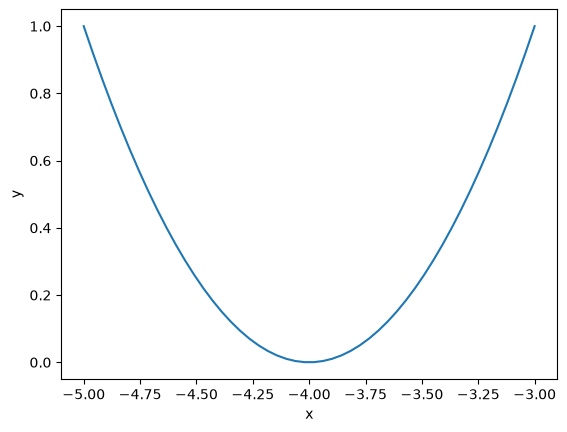

In [4]:
import matplotlib.pyplot as plt

X = np.linspace(-5, -3)
y = X**2 + 8 * X + 16
plt.plot(X, y)
plt.xlabel('x')
plt.ylabel('y');

Note that we get all the roots. A `Polynomial` object is callable, so we can check them by evaluating `poly(r)`.



In [5]:
?Polynomial.roots

In [6]:
poly(r)

array([1.77635684e-15, 1.77635684e-15])

We can also use this to plot a polynomial.



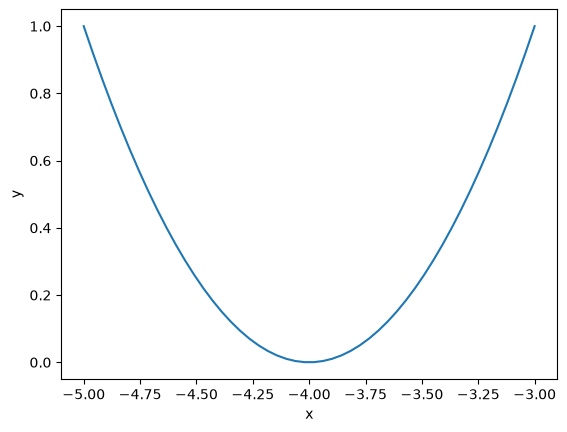

In [7]:
x = np.linspace(-5, -3)
y = poly(x)

plt.plot(x, y)
plt.xlabel("x")
plt.ylabel("y");

In [8]:
from scipy.optimize import root


def f(x):
    return poly(x)


root(f, -3.01)

 message: The solution converged.
 success: True
  status: 1
     fun: [ 0.000e+00]
       x: [-4.000e+00]
  method: hybr
    nfev: 39
    fjac: [[-1.000e+00]]
       r: [-9.792e-08]
     qtf: [-7.105e-15]

Why is this so convenient?



## Cubic equations of state



There are applications of polynomials in thermodynamics. The van der waal equation is a cubic polynomial $f(V) = V^3 - \frac{p n b + n R T}{p} V^2 + \frac{n^2 a}{p}V - \frac{n^3 a b}{p} = 0$, where $a$ and $b$ are constants, $p$ is the pressure, $R$ is the gas constant, $T$ is an absolute temperature and $n$ is the number of moles. The roots of this equation tell you the volume of the gas at those conditions.



In [9]:
# numerical values of the constants
a = 3.49e4
b = 1.45
p = 679.7  # pressure in psi
T = 683  # T in Rankine
n = 1.136  # lb-moles
R = 10.73  # ft^3 * psi / R / lb-mol

eos = Polynomial([
    -(n**3) * a * b / p,  # constant
    n**2 * a / p,  # V
    -(p * n * b + n * R * T) / p,  # V**2
    1.0,  # V**3
])

print(eos.roots())

[4.4006681 -1.43502848j 4.4006681 +1.43502848j 5.09432376+0.j        ]


In [10]:
rr = eos.roots()
(rr[0] * 2).imag

np.float64(-2.8700569658475126)

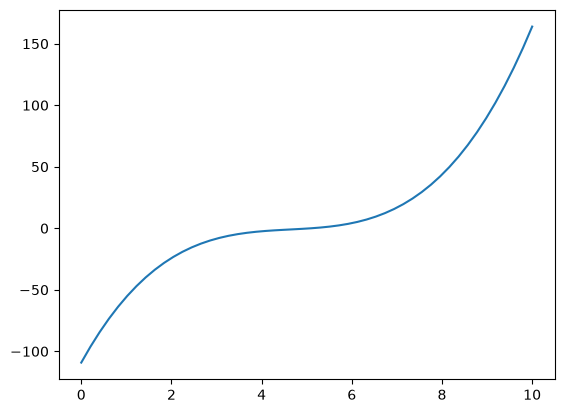

In [11]:
V = np.linspace(0, 10)
plt.plot(V, eos(V));

Note that only one root is real (and even then, we have to interpret 0.j as not being imaginary. Also, in a cubic polynomial, there can only be two imaginary roots). In this case that means there is only one phase present.

Remember root? Two of these roots are not accessible in root because they are imaginary.


## Other useful things to remember about polynomials



You can obtain the exact derivative as another `Polynomial` object with its `deriv` method.



In [12]:
?Polynomial.deriv

$y = x^2 + 8x + 16$


$y'(x) = 2x + 8$

In [13]:
pd = poly.deriv()
pd

Polynomial([8., 2.], domain=[-1.,  1.], window=[-1.,  1.], symbol='x')

The derivative polynomial is callable too. This is an *analytical* derivative—no numerical approximation is necessary.



In [14]:
pd(np.linspace(-5, -3))

array([-2.        , -1.91836735, -1.83673469, -1.75510204, -1.67346939,
       -1.59183673, -1.51020408, -1.42857143, -1.34693878, -1.26530612,
       -1.18367347, -1.10204082, -1.02040816, -0.93877551, -0.85714286,
       -0.7755102 , -0.69387755, -0.6122449 , -0.53061224, -0.44897959,
       -0.36734694, -0.28571429, -0.20408163, -0.12244898, -0.04081633,
        0.04081633,  0.12244898,  0.20408163,  0.28571429,  0.36734694,
        0.44897959,  0.53061224,  0.6122449 ,  0.69387755,  0.7755102 ,
        0.85714286,  0.93877551,  1.02040816,  1.10204082,  1.18367347,
        1.26530612,  1.34693878,  1.42857143,  1.51020408,  1.59183673,
        1.67346939,  1.75510204,  1.83673469,  1.91836735,  2.        ])

You can also obtain an antiderivative with the `integ` method. The integration constant is 0 by default.



In [15]:
?Polynomial.integ

In [16]:
pint = poly.integ()
pint

Polynomial([ 0.        , 16.        ,  4.        ,  0.33333333], domain=[-1.,  1.], window=[-1.,  1.], symbol='x')

You can use this to compute definite integrals, e.g. from x=1 to x=2:



In [17]:
?Polynomial.__call__

In [18]:
pint(2) - pint(1)

np.float64(30.33333333333334)

In [19]:
from scipy.integrate import quad


def integrand(x):
    return x**2 + 8 * x + 16


quad(integrand, 1, 2)

(30.333333333333332, 3.367676508029641e-13)

In [20]:
poly

Polynomial([16.,  8.,  1.], domain=[-1.,  1.], window=[-1.,  1.], symbol='x')

In [21]:
X = np.linspace(1, 2)
y = X**2 + 8 * X + 16
from scipy.integrate import simpson

simpson(y, X)

np.float64(30.333333333333336)

**exercise** Use another method to confirm the result above.

The `Polynomial` object already provides a convenient callable interface as well as methods for roots, derivatives, and integrals.



In [22]:
?Polynomial

In [23]:
pint(2) - pint(1)

np.float64(30.33333333333334)

In [24]:
pint

Polynomial([ 0.        , 16.        ,  4.        ,  0.33333333], domain=[-1.,  1.], window=[-1.,  1.], symbol='x')

In [25]:
pint.roots()

array([-6.-3.46410162j, -6.+3.46410162j,  0.+0.j        ])

In [26]:
?pint

In [27]:
print(pint)

0.0 + 16.0·x + 4.0·x² + 0.33333333·x³


In [28]:
pint.roots()

array([-6.-3.46410162j, -6.+3.46410162j,  0.+0.j        ])

In [29]:
[
    root.real for root in pint.roots() if np.abs(root.imag) <= 1e-12
]  # extract out only the real part of the real roots.

[np.float64(0.0)]

In [30]:
with np.printoptions(suppress=True):  # show very small numbers as 0
    print(pint(pint.roots()))

[0.+0.j 0.-0.j 0.+0.j]


In [31]:
pint.coef

array([ 0.        , 16.        ,  4.        ,  0.33333333])

In [32]:
pint.degree()

3

# Systems of nonlinear equations



```{note}
There is also `scipy.optimize.fsolve` which can also be used to solve nonlinear equations. This is an older function, and `root` is preferred for new code.
```

Analogously to systems of ordinary differential equations, with systems of nonlinear equations we define functions that will return a zero for each equation in the system. Then we have to pass an initial guess for each variable to root, and it will return an array of values, one for each variable.

It is considerably more difficult to visualize systems of nonlinear equations. With two equations and two unknowns it is sometimes easy to plot solutions, but not always.

\begin{align}
y &=& x^2 \\
y &=& 8 - x^2
\end{align}

One approach to visualizing this is to plot the two curves.



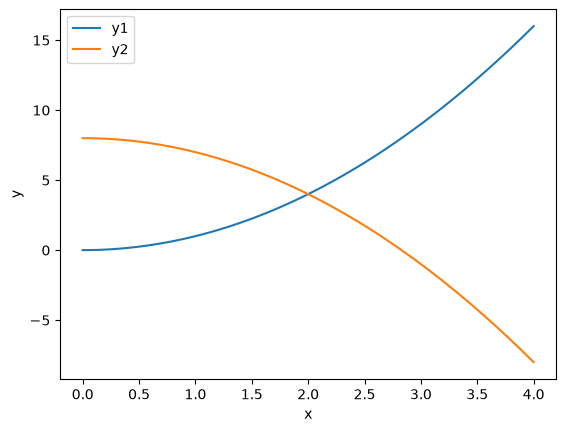

In [33]:
import numpy as np
import matplotlib.pyplot as plt

x = np.linspace(0, 4)

y1 = x**2
y2 = 8 - x**2

plt.plot(x, y1, x, y2)
plt.xlabel("x")
plt.ylabel("y")
plt.legend(["y1", "y2"]);

You can see that on this domain, there is one place where the two curves intersect near the point (2, 5), which is a solution point. At this point there is one (x, y) pair that is a solution to *both* equations.

In [34]:
from scipy.optimize import root


def objective(X):
    x, y = X
    z1 = y - x**2
    z2 = y - 8 + x**2
    return np.array([z1, z2])


guess = [2, 3.6]
objective(guess)

array([-0.4, -0.4])

In [35]:
ans = root(objective, guess)  

ans

 message: The solution converged.
 success: True
  status: 1
     fun: [ 0.000e+00  0.000e+00]
       x: [ 2.000e+00  4.000e+00]
  method: hybr
    nfev: 7
    fjac: [[-7.071e-01  7.071e-01]
           [-7.071e-01 -7.071e-01]]
       r: [ 5.657e+00  5.070e-16 -1.414e+00]
     qtf: [-2.341e-09  1.405e-09]

In [36]:
sol = root(objective, guess)  # we unpack the two parts of the solution into x and y
x, y = sol.x

In [37]:
[
    objective((x, y)),  # tuple
    objective([x, y]),  # list
    # use an array
    objective(np.array([x, y])),
]  # three equivalent ways to call the objective function

[array([0., 0.]), array([0., 0.]), array([0., 0.])]

In [38]:
objective(ans.x)

array([0., 0.])

In [39]:
objective(guess)

array([-0.4, -0.4])

# A harder example

It is not always easy to solve for one variable in terms of the other though. In that case, we can resort to an alternate graphical approach where we evaluate the objective function over a range of the variables, and look for regions where they overlap.

Consider the solution to these equations (adapted from [https://www.mathworks.com/help/optim/ug/fsolve.html](https://www.mathworks.com/help/optim/ug/fsolve.html)):

$e^{-e^{-(x_1 + x_2)}} = x_2 (1 + x_1^2)$

and

$x_1 \cos(x_2) + x_2 \sin(x_1) = 1/2$

It is not possible to solve either one for one variable in terms of the other. So instead, we will compute the objective function for a range of $x_1, x_2$ values, and then use a contour plot of each equation to see where there might be a solution.

The key to this visualization is where we draw the contours. A good choice is to highlight only the part of the solutions that bracket zero. Then we can see where they intersect, because there is probably a solution in that neighborhood.



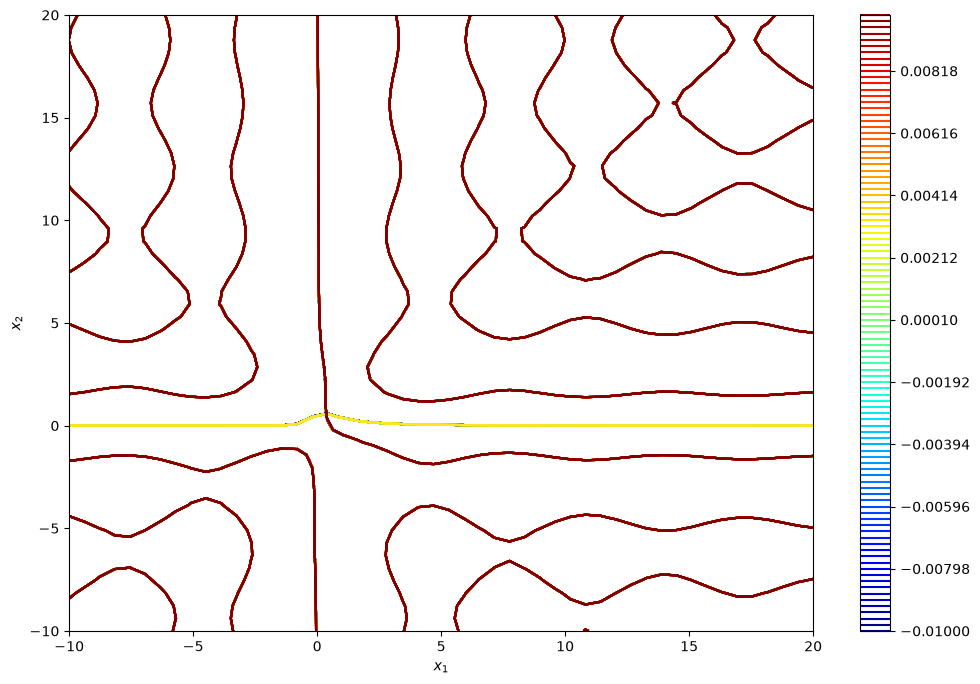

In [40]:
import numpy as np


def objective(X):
    x1, x2 = X
    z1 = np.exp(-np.exp(-(x1 + x2))) - x2 * (1 + x1**2)
    z2 = x1 * np.cos(x2) + x2 * np.sin(x1) - 0.5
    return np.array([z1, z2])


x1 = np.linspace(-10, 20)
x2 = np.linspace(-10, 20)

X1, X2 = np.meshgrid(x1, x2)

Z1, Z2 = objective([X1, X2])
plt.figure(figsize=(12, 8))
plt.contour(X1, X2, Z1, levels=np.linspace(-0.01, 0.01, 100))
plt.contour(X1, X2, Z2, levels=np.linspace(-0.01, 0.01, 100), cmap="jet")
plt.xlabel("$x_1$")
plt.ylabel("$x_2$")
plt.colorbar();

In [41]:
objective([0.4, 0.6])  # shows that the objective function is approximately zero

array([-0.00379937,  0.06378525])

There is an intersection near $x_1=0.4$, and $x_2 = 0.6$. We can use that as an initial guess.

In [42]:
from scipy.optimize import root

ans = root(objective, [2.5, 2.5])  
ans, objective(ans.x)

( message: The solution converged.
  success: True
   status: 1
      fun: [ 1.090e-13 -2.676e-14]
        x: [ 3.532e-01  6.061e-01]
   method: hybr
     nfev: 23
     fjac: [[-1.114e-01  9.938e-01]
            [-9.938e-01 -1.114e-01]]
        r: [ 1.396e+00  2.402e-01  8.425e-01]
      qtf: [ 3.050e-10  8.300e-10],
 array([ 1.09023901e-13, -2.67563749e-14]))

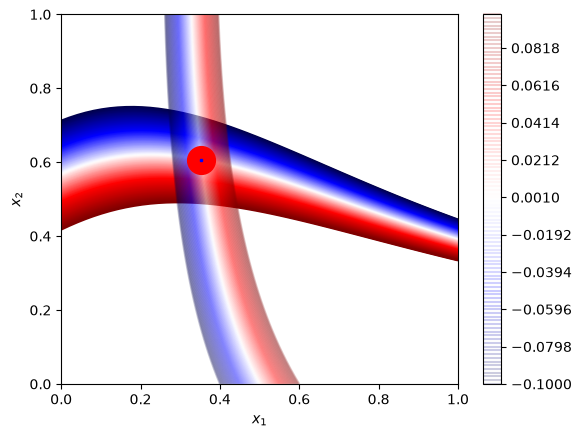

In [43]:
x1 = np.linspace(0, 1)
x2 = np.linspace(0, 1)

X1, X2 = np.meshgrid(x1, x2)
Z1, Z2 = objective([X1, X2])
plt.contour(X1, X2, Z1, levels=np.linspace(-0.1, 0.1, 100), cmap="seismic")
plt.contour(
    X1, X2, Z2, levels=np.linspace(-0.1, 0.1, 100), cmap="seismic", alpha=0.2
)  # set a colormap
plt.plot(*ans.x, "ro", ms=20)
plt.plot(*ans.x, "bs", ms=2)
plt.xlabel("$x_1$")
plt.ylabel("$x_2$")
plt.colorbar();

This shows the solution, and that the objective is practically equal to zero at that point.

You can see that trying to do this in more than 2 dimensions can quickly get difficult to visualize!



In [44]:
# show that we only get one solution by brute force iteration over all the grid points
I, J = X1.shape
solns = []
for i in range(I):
    for j in range(J):
        x1, x2 = X1[i, j], X2[i, j]
        ans = root(objective, [x1, x2])
        solns += [ans.x]

solns = np.array(solns)

(np.mean(solns, axis=0), np.std(solns, axis=0))

(array([0.35324662, 0.60608174]), array([6.13078510e-12, 1.45204397e-11]))

In [45]:
solns.shape

(2500, 2)

In [46]:
50**10 * 16 / 1024 / 1024 / 1024  # Estimate of memory required to store 50**10 floats in an array

1455191522.8366852

# Summary



-   We learned about a special class of nonlinear functions that are polynomials, and a series of useful functions to manipulate them.

-   We learned that you can use root to find solutions to coupled non-linear algebraic equations.

-   Next time, we will apply this to solving a nonlinear boundary value differential equation.

```{note}
This notebook uses NumPy's preferred [`numpy.polynomial`](https://numpy.org/doc/stable/reference/routines.polynomials.html) API. Remember that `Polynomial` stores coefficients in **increasing** order of degree: `[c0, c1, c2]` represents $c_0 + c_1x + c_2x^2$.

```

In [1]:
from jupyterquiz import display_quiz
display_quiz('.quiz.json')

<IPython.core.display.Javascript object>